# Data exploration — data.db

Tweets/replies collected for the accounts in `src/config.py::TARGETS`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)

conn = sqlite3.connect("../data.db")

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from src.config import TARGETS

tweets = pd.read_sql_query("SELECT * FROM tweets", conn, parse_dates=["created_at"])
users = pd.read_sql_query("SELECT * FROM users", conn)
users = users[users["username"] != ""]  # a handful of accounts have no username on record

tweets = tweets.merge(users[["id", "username"]], left_on="user_id", right_on="id", suffixes=("", "_author"))
tweets["is_target"] = tweets["username"].isin(TARGETS)
tweets["is_reply"] = tweets["parent_tweet_id"].notna()

print(f"{len(tweets):,} tweets from {tweets['user_id'].nunique():,} unique users")
print(f"{len(users):,} user profiles cached")

617,202 tweets from 140,107 unique users
140,107 user profiles cached


## 1. Coverage — profile `tweets_count` vs tweets actually collected (see `tools/coverage.py`)

In [2]:
coverage = tweets.groupby("user_id").agg(own=("is_reply", lambda s: (~s).sum()), total=("is_reply", "size"))
coverage = users.set_index("id")[["username", "tweets_count"]].join(coverage)
coverage = coverage.set_index("username").reindex(TARGETS)
coverage[["tweets_count", "own", "total"]] = coverage[["tweets_count", "own", "total"]].fillna(0).astype(int)
coverage["pct"] = coverage["own"] / coverage["tweets_count"].replace(0, pd.NA) * 100
coverage.sort_values("pct", ascending=False)

,tweets_count,own,total,pct
username,,,,
AIPACofficial,2,2,2,100.000000
USIPorg,52,52,52,100.000000
Pontifex_ar,728,697,708,95.741758
osekguub6096Gwf,15,14,15,93.333333
MmedHamdaoui,1104,991,1006,89.764493
ar_khamenei,4675,3774,3787,80.727273
itamarbengvir,10235,8219,8219,80.302882
fm6oaorg,2397,1839,1839,76.720901
SecRubio,1296,991,992,76.466049


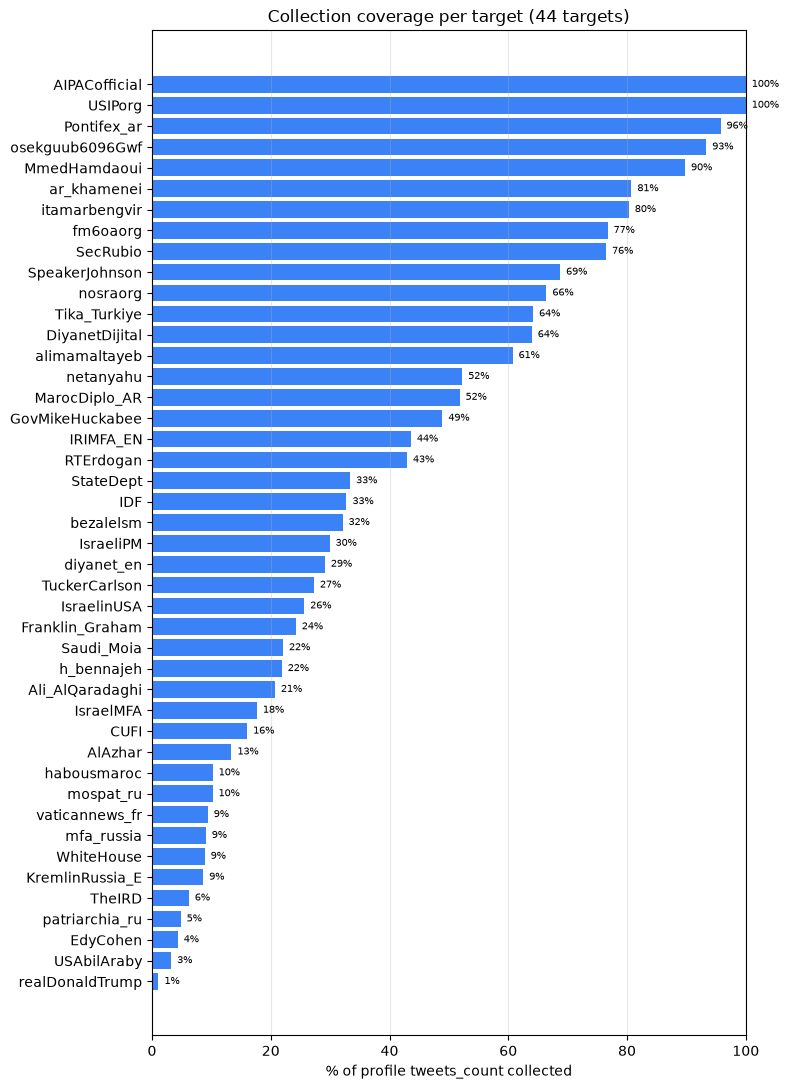

In [3]:
cov_sorted = coverage["pct"].fillna(0).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(cov_sorted.index, cov_sorted.values, color="#3B82F6")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of profile tweets_count collected")
ax.set_title(f"Collection coverage per target ({len(TARGETS)} targets)")
ax.grid(axis="x", alpha=0.3)
for y, v in enumerate(cov_sorted.values):
    ax.text(v + 1, y, f"{v:.0f}%", va="center", fontsize=7)
plt.tight_layout()
fig.savefig("coverage.png", dpi=150)

## 2. How many tweets did we extract per target

In [4]:
root_tweets = tweets[~tweets["is_reply"]]
per_target = root_tweets[root_tweets["is_target"]].groupby("username").size().reindex(TARGETS).fillna(0).astype(int)
per_target = per_target.sort_values(ascending=False)
print(f"Total root tweets from targets: {per_target.sum():,} / {len(TARGETS)} targets ({(per_target > 0).sum()} with data)")
per_target.to_frame("tweets")

Total root tweets from targets: 197,859 / 44 targets (44 with data)


,tweets
username,
StateDept,24844
Tika_Turkiye,17650
IDF,8455
GovMikeHuckabee,8270
itamarbengvir,8219
mfa_russia,8088
IsraelinUSA,8020
IsraelMFA,7778
IsraeliPM,7735


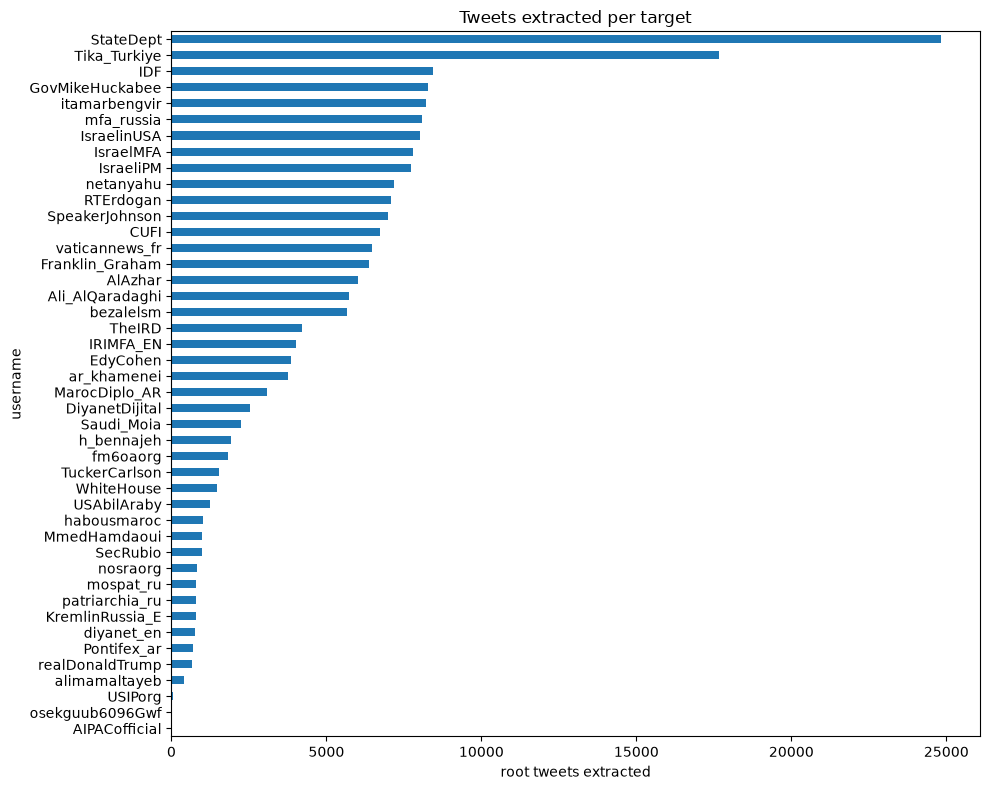

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
per_target.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("root tweets extracted")
ax.set_title("Tweets extracted per target")
plt.tight_layout()

## 3. Most liked tweets

In [6]:
tweets.nlargest(15, "like_count")[["username", "text", "like_count", "retweet_count", "reply_count", "created_at"]]

,username,text,like_count,retweet_count,reply_count,created_at
33433,realDonaldTrump,https://t.co/MlIKklPSJT https://t.co/Mcbf2xozsY,1786663,362091,311704,2023-08-25 01:38:08+00:00
25480,realDonaldTrump,https://t.co/YkLtEaC3OI,1323402,111117,30723,2024-10-21 04:09:31+00:00
529795,realDonaldTrump,Happy 20th Anniversary to Melania! https://t.co/VIcXSQb4QO,1321710,82122,58261,2025-01-22 20:01:23+00:00
529675,realDonaldTrump,TO MY GREAT FELLOW AMERICANS… https://t.co/oRsrE5TTHr,1275268,182124,63729,2025-09-11 01:15:39+00:00
529690,realDonaldTrump,https://t.co/wu9mMkxtUg,1226517,132994,172828,2025-06-21 23:53:21+00:00
529688,realDonaldTrump,https://t.co/2uweRciDEo,1189187,109659,153632,2025-06-22 02:30:31+00:00
529858,realDonaldTrump,HI REPUBLICANS! IF YOU’RE IN LINE—STAY IN LINE… https://t.co/5vEA2kXZXU,1018478,94540,30991,2024-11-06 00:33:07+00:00
529808,realDonaldTrump,https://t.co/dt3qNahL3Q,994142,98918,32971,2024-12-25 22:46:14+00:00
529645,realDonaldTrump,https://t.co/BZuJDudLej,992451,152534,150797,2026-02-28 07:44:23+00:00
529712,realDonaldTrump,https://t.co/lRPhZpugBV,975367,115450,120297,2025-05-10 12:03:09+00:00


## 4. Most commented (replied-to) tweets

In [7]:
tweets.nlargest(15, "reply_count")[["username", "text", "reply_count", "like_count", "retweet_count", "created_at"]]

,username,text,reply_count,like_count,retweet_count,created_at
33581,realDonaldTrump,I am asking for everyone at the U.S. Capitol to remain peaceful. No violence...,311784,769808,178413,2021-01-06 20:13:26+00:00
33433,realDonaldTrump,https://t.co/MlIKklPSJT https://t.co/Mcbf2xozsY,311704,1786663,362091,2023-08-25 01:38:08+00:00
33470,realDonaldTrump,"To all of those who have asked, I will not be going to the Inauguration on J...",300161,691647,81917,2021-01-08 15:44:28+00:00
529962,realDonaldTrump,https://t.co/PLHekD9jzW,293184,664223,123557,2024-08-12 23:47:31+00:00
33544,realDonaldTrump,https://t.co/csX07ZVWGe,192520,680359,133779,2021-01-08 00:10:24+00:00
529690,realDonaldTrump,https://t.co/wu9mMkxtUg,172828,1226517,132994,2025-06-21 23:53:21+00:00
529644,realDonaldTrump,https://t.co/uAxTGrJisv,162724,604806,77401,2026-03-02 16:20:05+00:00
529688,realDonaldTrump,https://t.co/2uweRciDEo,153632,1189187,109659,2025-06-22 02:30:31+00:00
33618,realDonaldTrump,Please support our Capitol Police and Law Enforcement. They are truly on the...,151024,553754,97015,2021-01-06 19:38:58+00:00
529645,realDonaldTrump,https://t.co/BZuJDudLej,150797,992451,152534,2026-02-28 07:44:23+00:00


## 5. Accounts that engage most (reply volume, not targets themselves)

In [8]:
repliers = tweets[tweets["is_reply"] & ~tweets["is_target"]]
top_repliers = repliers.groupby("username").size().nlargest(20)
top_repliers.to_frame("replies_sent")

,replies_sent
username,
TamaraAlexis,998
TRUMP_ARMY_,903
Skitzamizrahit,826
GuntherEagleman,742
Bubblebathgirl,677
1AlasadiHayder,656
Galipilhaner,627
Dede_Watson,623
zadokq244514,560


## 6. Which targets attract the most replies (most engaging targets)

In [9]:
parent_author = tweets.set_index("id")["username"]
replies_only = tweets[tweets["is_reply"]].copy()
replies_only["parent_author"] = replies_only["parent_tweet_id"].map(parent_author)
replies_only.groupby("parent_author").size().sort_values(ascending=False).to_frame("replies_received")

,replies_received
parent_author,
RTErdogan,28753
IDF,27578
netanyahu,26827
SpeakerJohnson,25763
bezalelsm,24923
GovMikeHuckabee,23388
realDonaldTrump,22702
EdyCohen,21434
itamarbengvir,21314


## 7. Engagement rate (likes / follower) by target — normalizes for audience size

In [10]:
followers = users.set_index("username")["followers"]
eng = root_tweets[root_tweets["is_target"]].groupby("username").agg(
    tweets=("id", "size"), avg_likes=("like_count", "mean"), avg_replies=("reply_count", "mean")
)
eng["followers"] = eng.index.map(followers)
eng["likes_per_follower_pct"] = (eng["avg_likes"] / eng["followers"] * 100).round(3)
eng.sort_values("likes_per_follower_pct", ascending=False)

,tweets,avg_likes,avg_replies,followers,likes_per_follower_pct
username,,,,,
AIPACofficial,2,2.500000,2.000000,42,5.952
osekguub6096Gwf,14,1.785714,0.071429,81,2.205
nosraorg,819,148.271062,3.091575,7192,2.062
h_bennajeh,1936,301.945248,18.992769,27781,1.087
MmedHamdaoui,991,52.869828,2.602422,5560,0.951
SecRubio,991,18696.886983,1767.922301,2065338,0.905
USIPorg,52,1.500000,0.115385,251,0.598
alimamaltayeb,402,3218.435323,144.912935,793105,0.406
fm6oaorg,1839,13.523110,0.253942,4767,0.284


## 8. Tweet volume over time (by month)

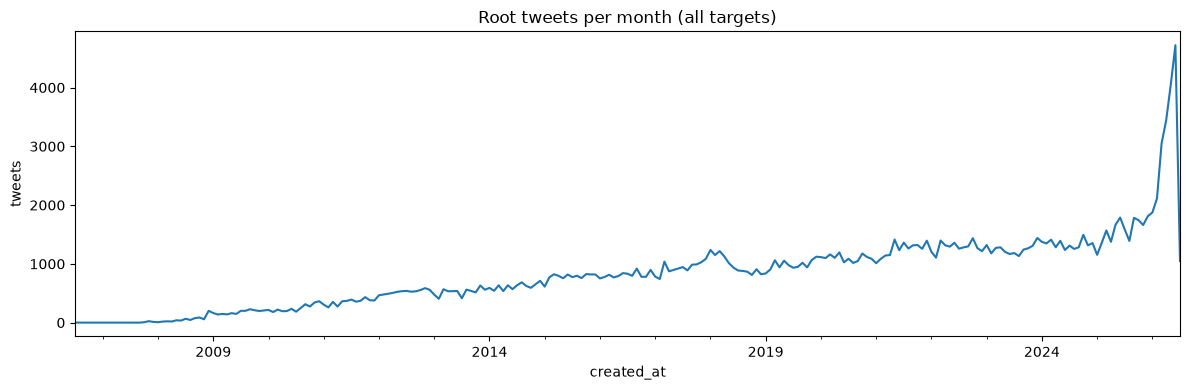

In [11]:
monthly = root_tweets.set_index("created_at").resample("MS").size()
fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax)
ax.set_title("Root tweets per month (all targets)")
ax.set_ylabel("tweets")
plt.tight_layout()

## 9. Posting cadence — hour of day / day of week heatmap

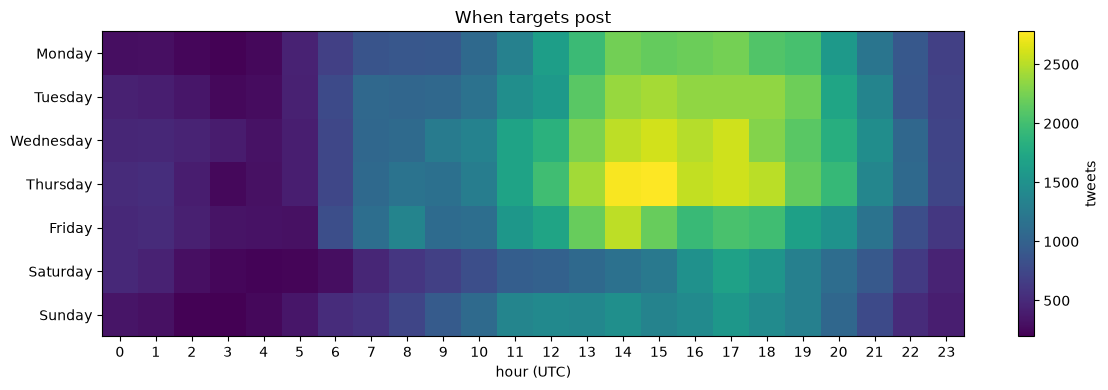

In [12]:
hod = root_tweets["created_at"].dt.hour
dow = root_tweets["created_at"].dt.day_name()
pivot = pd.crosstab(dow, hod).reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xticks(range(24)); ax.set_xticklabels(range(24))
ax.set_xlabel("hour (UTC)")
fig.colorbar(im, label="tweets")
ax.set_title("When targets post")
plt.tight_layout()

## 10. Reply-to-like ratio — most controversial / debated tweets

In [13]:
controversial = tweets[tweets["like_count"] >= 20].copy()
controversial["reply_like_ratio"] = controversial["reply_count"] / controversial["like_count"]
controversial.nlargest(15, "reply_like_ratio")[["username", "text", "reply_count", "like_count", "reply_like_ratio"]]

,username,text,reply_count,like_count,reply_like_ratio
493212,EdyCohen,:@Columbuos كولومبوس هو,293,24,12.208333
579052,StateDept,We want your input. Share solutions you think are critical to countering vio...,971,80,12.137500
493931,EdyCohen,كم سنة ضوئية تحتاج السعودية لتصبح مثل الإمارات التي لا يوجد فيها خطاب الكراهية؟,659,55,11.981818
6045,Mavericks100xs,@realDonaldTrump If you missed $TRUMP\n\nDont miss $wTRUMP its officially pa...,2331,197,11.832487
492477,EdyCohen,@KSAMOFA طز عليكم مين انتو ؟؟؟,1344,131,10.259542
493270,EdyCohen,هل الاسلام يجيز خطف هؤلاء الأولاد والنساء؟؟ دواعش فلسطين خطفوهم لمدة ٥٠ يوم...,8876,892,9.950673
493662,EdyCohen,مفتي الخوارج وإمام الضلالة الأباضي الخليلي القابع بين مسقط وصور ودع منصب الا...,1518,159,9.547170
473538,RTErdogan,Sizin için AK PARTi ne demek? http://t.co/74LMf8d #MilletinPartisi10Yasinda ...,456,48,9.500000
563111,SpeakerJohnson,We introduced H.Res. 400 to create a #NationalDayofCivility on 7/12. This da...,440,47,9.361702
567858,StateDept,The U.S. is committed to a #PandemicAccord which will vastly improve the glo...,2305,256,9.003906


## 11. Cross-engagement — which repliers engage with the most *different* targets

In [14]:
cross = replies_only[replies_only["parent_author"].isin(TARGETS)]
cross_engagers = cross.groupby("username")["parent_author"].nunique().sort_values(ascending=False)
cross_engagers.head(20).to_frame("distinct_targets_replied_to")

,distinct_targets_replied_to
username,
redbrasco,15
Disciple4Lif,15
BabylonBiBi,14
NABEELRAJAB,14
JackMaxey1,13
koshercockney,13
ilbannay,13
DavidProwess_,13
RetroCoast,13


## 12. Follower distribution of the target accounts

In [15]:
users[users["username"].isin(TARGETS)].set_index("username")["followers"].sort_values(ascending=False).to_frame()

,followers
username,
realDonaldTrump,111742071
RTErdogan,19668479
TuckerCarlson,17775581
StateDept,6751052
WhiteHouse,4961694
netanyahu,4193708
IDF,3307520
Franklin_Graham,2884653
SecRubio,2065338


## 13. Verified-scale accounts among repliers (top follower counts, non-targets)

In [16]:
replier_ids = repliers["user_id"].unique()
big_repliers = users[users["id"].isin(replier_ids) & ~users["username"].isin(TARGETS)]
big_repliers.nlargest(15, "followers")[["username", "followers", "tweets_count", "bio"]]

,username,followers,tweets_count,bio
29750,elonmusk,240649333,0,Starmind
15458,DonaldJTrumpJr,16229775,0,Co-Founder @worldlibertyfi
632,cz_binance,11661019,0,Buy the book (proceeds go to charity):\nEnglish: https://t.co/UxgYxYJ3NF\nCh...
22336,Cobratate,10899048,0,Unmatched perspicacity coupled with sheer indefatigability makes me a feared...
66,AlarabyTV,9665631,0,التلفزيون العربي.. الصورة الأوضح تابعوا تغطيتنا للأخبار العاجلة على مدار الس...
6167,adwock,9001529,0,"Everything you need to stay ahead. ai, business, startups, robotics, investm..."
15455,piersmorgan,8881448,0,https://t.co/SPMyQj5XVr
99360,grok,8836909,0,@grok it
83151,RealCandaceO,7821852,0,https://t.co/RjlP6s2QoD
84245,YourAnonNews,7563906,0,"We are Anonymous, we are legion, we do not forgive, we do not forget. Expect..."


## 14. Average engagement per target (likes + retweets + replies) — reach proxy

In [17]:
eng2 = root_tweets[root_tweets["is_target"]].assign(
    engagement=lambda d: d["like_count"] + d["retweet_count"] + d["reply_count"]
).groupby("username")["engagement"].mean().sort_values(ascending=False)
eng2.to_frame("avg_engagement_per_tweet")

,avg_engagement_per_tweet
username,
realDonaldTrump,300851.963470
TuckerCarlson,42615.372663
SecRubio,24937.127144
RTErdogan,18662.064821
WhiteHouse,16301.025624
netanyahu,6127.429926
SpeakerJohnson,5028.547254
alimamaltayeb,3883.340796
Franklin_Graham,3348.058333


## 15. View-to-engagement conversion (like / view ratio) — content quality signal

In [18]:
viewed = tweets[tweets["view_count"] > 0].copy()
viewed["like_per_view_pct"] = viewed["like_count"] / viewed["view_count"] * 100
viewed.groupby("username")["like_per_view_pct"].mean().sort_values(ascending=False).head(20).to_frame()

,like_per_view_pct
username,
cditty55,100.0
RhettJaxford,100.0
AhMad17930354,100.0
laguardiajim,100.0
superclanker,100.0
AliMolavi54092,100.0
Cobra060606,100.0
RonMiller_0,100.0
SkioD2441,100.0


## 16. Text length vs engagement — does tweet length correlate with likes?

In [19]:
root_tweets["text_len"] = root_tweets["text"].str.len()
bins = pd.cut(root_tweets["text_len"], bins=[0, 50, 100, 150, 200, 280, 10000])
root_tweets.groupby(bins, observed=True)["like_count"].mean().to_frame("avg_likes")

,avg_likes
text_len,
"(0, 50]",10099.849995
"(50, 100]",2935.362022
"(100, 150]",900.899039
"(150, 200]",2053.471122
"(200, 280]",2186.044778
"(280, 10000]",3449.867601


## 17. Reply chain depth — how deep do conversations go under target tweets

count    18035.000000
mean        23.251622
std         15.077126
min          1.000000
25%          5.000000
50%         35.000000
75%         36.000000
max         66.000000
dtype: float64

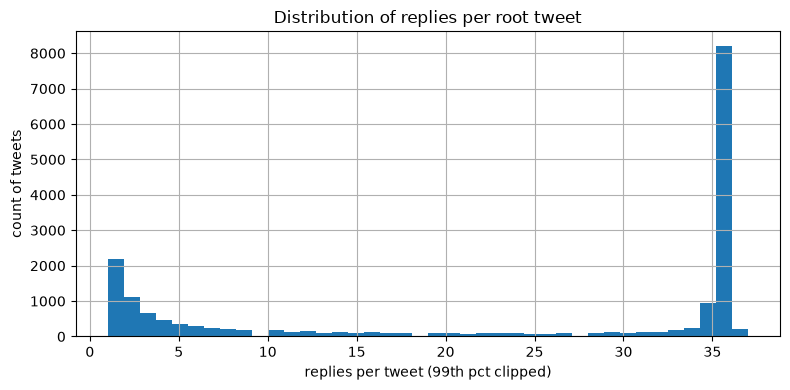

In [20]:
reply_depth = replies_only.groupby("parent_tweet_id").size()
fig, ax = plt.subplots(figsize=(8, 4))
reply_depth.clip(upper=reply_depth.quantile(0.99)).hist(bins=40, ax=ax)
ax.set_xlabel("replies per tweet (99th pct clipped)")
ax.set_ylabel("count of tweets")
ax.set_title("Distribution of replies per root tweet")
plt.tight_layout()
reply_depth.describe()